# Modelo Analítico: Flujo 2D Viscoso con Transferencia de Calor y Placa Móvil

## 1. Hipótesis
- Flujo **incompresible** ($\nabla \cdot \mathbf{u} = 0$) y **laminar**.
- Dominio **bidimensional** (variaciones en $x$ y $y$).
- Placa inferior ($y = 0$) se mueve con velocidad $-U_p \hat{i}$ (sentido $-x$).
- Gradiente de presión constante en $x$: $\frac{\partial p}{\partial x} = \text{const.}$
- Efectos gravitacionales despreciables.

## 2. Ecuaciones Gobernantes

### Conservación de Momento (Navier-Stokes 2D)
**Componente $x$**:
$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial x} + \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$

**Componente $y$**:
$$
\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial y} + \nu \left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right)
$$

donde:
- $u$, $v$: Componentes de velocidad en $x$ e $y$.
- $\nu = \mu/\rho$: Viscosidad cinemática.

### Conservación de Energía
$$
\frac{\partial T}{\partial t} + u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} = \alpha \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right) + \frac{\Phi}{\rho c_p}
$$

**Disipación viscosa ($\Phi$)**:
$$
\Phi = \mu \left[ 2 \left( \frac{\partial u}{\partial x} \right)^2 + 2 \left( \frac{\partial v}{\partial y} \right)^2 + \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)^2 \right]
$$

### Esfuerzo Cortante ($\tau_{xy}$)
$$
\tau_{xy} = \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)
$$

## 3. Condiciones de Frontera

<center>

| **Variable**   | **Placa Inferior ($y=0$)**       | **Superior ($y=H$)**       |
|----------------|----------------------------------|----------------------------|
| Velocidad $u$  | $u = -U_p$                       | $u = U_0$                  |
| Velocidad $v$  | $v = 0$ (no penetración)         | $v = 0$                    |
| Temperatura $T$| $T = T_0$                        | $T = T_1$                  |

</center>

## 4. Simplificaciones para Estado Estacionario
Si $\frac{\partial}{\partial t} = 0$ y $\frac{\partial p}{\partial x} = -\Delta p/L$:
$$
\nu \frac{d^2 u}{dy^2} = \frac{1}{\rho} \frac{\Delta p}{L}, \quad \text{con} \quad u(0) = -U_p, \quad u(H) = U_0
$$

**Solución analítica** para $u(y)$:
$$
u(y) = \frac{\Delta p}{2 \mu L} y (y - H) + \left(U_0 + U_p \frac{y}{H}\right) - U_p


Presión máxima: 0.0000 en (0.78, 0.00)
Presión mínima: 0.0000 en (0.00, 0.12)


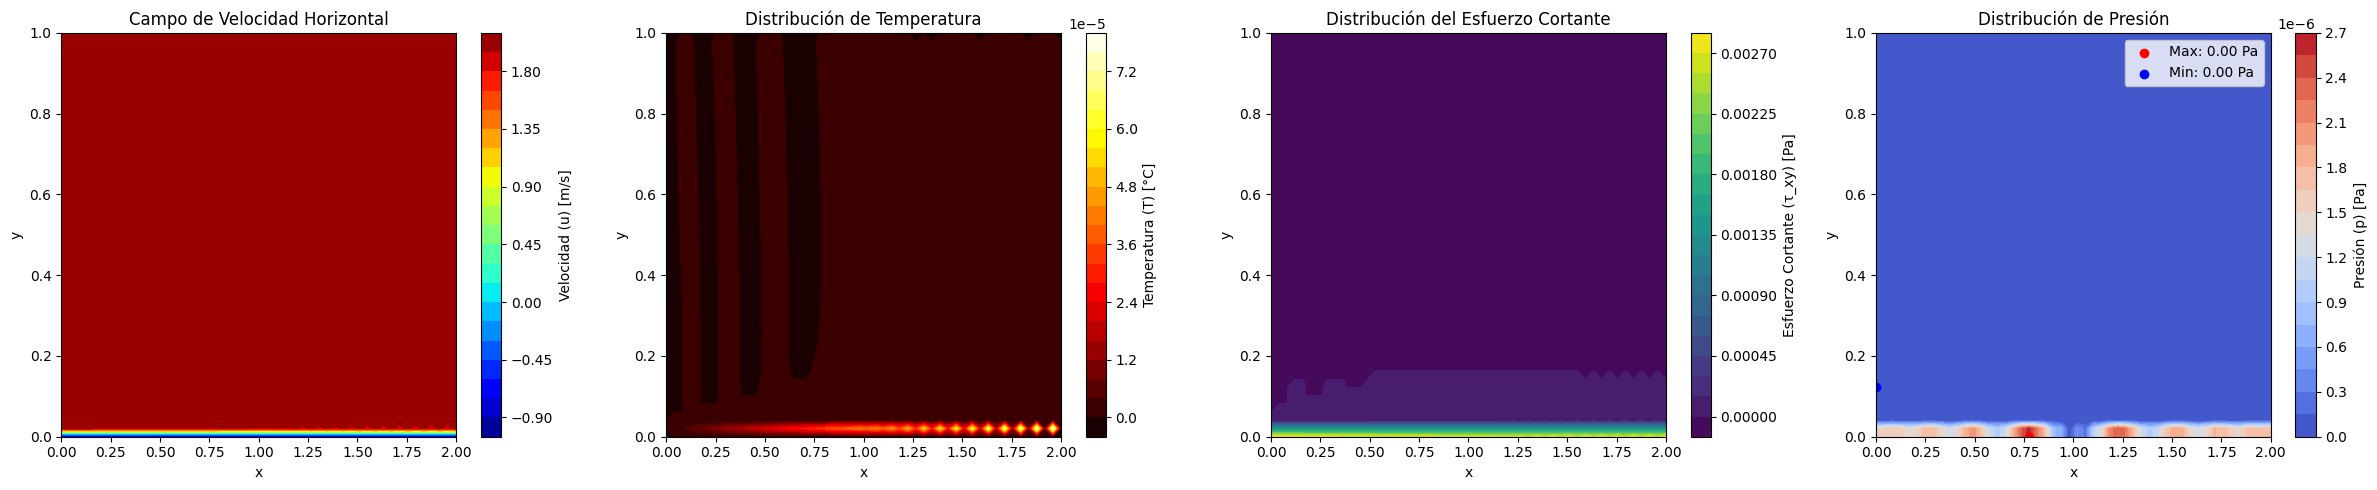

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# PARAMETROS DEL PROBLEMA
# Geometría
Lx, Ly = 2.0, 1.0  # Dimensiones del dominio (x, y)
nx, ny = 50, 50      # Número de puntos en la malla
dx, dy = Lx/(nx-1), Ly/(ny-1)

# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]

# Condiciones de frontera
U_p = -1.0           # Velocidad de la placa (sentido contrario)
U_0 = 2.0            # Velocidad del flujo libre
T0, T1 = 0.0, 0.0    # Temperaturas de la placa y del fluido

# Tiempo
dt = 0.001           # Paso de tiempo
nt = 500             # Número de pasos de tiempo

## INICIALIZACIÓN

# Mallas
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Campos iniciales
u = np.zeros((ny, nx)) + U_0  # Velocidad horizontal
v = np.zeros((ny, nx))         # Velocidad vertical
T = np.zeros((ny, nx)) + T1    # Temperatura
p = np.zeros((ny, nx))         # Presión

# Aplicar condiciones de frontera
u[0, :] = U_p     # Placa inferior móvil
u[-1, :] = U_0    # Flujo libre superior
T[0, :] = T0      # Temperatura de la placa
T[-1, :] = T1     # Temperatura del fluido lejos de la 


# EVOLUCIÓN TEMPORAL (ESQUEMA EXPLICITO)
for n in range(nt):
    # Copiar campos anteriores
    u_old = u.copy()
    v_old = v.copy()
    T_old = T.copy()

    # Resolver Navier-Stokes (simplificado)
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Ecuación de u (componente x)
            u[i, j] = (u_old[i, j] + dt * (
                -u_old[i, j] * (u_old[i, j+1] - u_old[i, j-1]) / (2*dx)
                -v_old[i, j] * (u_old[i+1, j] - u_old[i-1, j]) / (2*dy)
                + nu * (
                    (u_old[i, j+1] - 2*u_old[i, j] + u_old[i, j-1]) / dx**2
                    + (u_old[i+1, j] - 2*u_old[i, j] + u_old[i-1, j]) / dy**2
                )
            ))

            # Ecuación de T (temperatura)
            T[i, j] = (T_old[i, j] + dt * (
                -u_old[i, j] * (T_old[i, j+1] - T_old[i, j-1]) / (2*dx)
                -v_old[i, j] * (T_old[i+1, j] - T_old[i-1, j]) / (2*dy)
                + alpha * (
                    (T_old[i, j+1] - 2*T_old[i, j] + T_old[i, j-1]) / dx**2
                    + (T_old[i+1, j] - 2*T_old[i, j] + T_old[i-1, j]) / dy**2
                )
                + (mu / (rho * cp)) * (  # Disipación viscosa (simplificada)
                    2 * ((u_old[i, j+1] - u_old[i, j-1]) / (2*dx))**2
                    + 2 * ((v_old[i+1, j] - v_old[i-1, j]) / (2*dy))**2
                    + ((u_old[i+1, j] - u_old[i-1, j]) / (2*dy) 
                      + (v_old[i, j+1] - v_old[i, j-1]) / (2*dx))**2
                )
            ))

    # Aplicar condiciones de frontera nuevamente
    u[0, :] = U_p
    u[-1, :] = U_0
    v[:, 0] = v[:, -1] = 0
    T[0, :] = T0
    T[-1, :] = T1

# Cálculo de la presión mediante ecuación de Poisson (simplificado)
# Usamos una aproximación simple basada en la divergencia del campo de velocidad
max_iter = 500  # Número máximo de iteraciones para el solver de presión
tolerance = 1e-4  # Tolerancia para la convergencia

# Inicialización del campo de presión
p = np.zeros((ny, nx))

# Solver iterativo para la presión
for _ in range(max_iter):
    p_old = p.copy()
    
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Aproximación discreta de la ecuación de Poisson para la presión
            p[i, j] = 0.25 * (p_old[i+1, j] + p_old[i-1, j] + 
                             p_old[i, j+1] + p_old[i, j-1] -
                             (rho * dx**2) * (
                                 (u[i+1, j] - u[i-1, j]) / (2*dy) * (v[i, j+1] - v[i, j-1]) / (2*dx) -
                                 ((u[i, j+1] - u[i, j-1]) / (2*dx))**2 -
                                 ((v[i+1, j] - v[i-1, j]) / (2*dy))**2
                             ))
    
    # Condiciones de frontera para la presión (Neumann homogéneas)
    p[0, :] = p[1, :]   # Frontera inferior
    p[-1, :] = p[-2, :] # Frontera superior
    p[:, 0] = p[:, 1]   # Frontera izquierda
    p[:, -1] = p[:, -2] # Frontera derecha
    
    # Criterio de convergencia
    if np.max(np.abs(p - p_old)) < tolerance:
        break

# Encontrar los valores máximos y mínimos de presión
p_max = np.max(p)
p_min = np.min(p)
p_max_coords = np.unravel_index(np.argmax(p), p.shape)
p_min_coords = np.unravel_index(np.argmin(p), p.shape)

# Convertir índices a coordenadas físicas
p_max_x, p_max_y = x[p_max_coords[1]], y[p_max_coords[0]]
p_min_x, p_min_y = x[p_min_coords[1]], y[p_min_coords[0]]

print(f"\nPresión máxima: {p_max:.4f} en ({p_max_x:.2f}, {p_max_y:.2f})")
print(f"Presión mínima: {p_min:.4f} en ({p_min_x:.2f}, {p_min_y:.2f})")

# REPRESENTACIÓN GRÁFICA ACTUALIZADA
plt.figure(figsize=(24, 5))

# Gráfico de velocidad
plt.subplot(1, 4, 1)
plt.contourf(X, Y, u, levels=20, cmap='jet')
plt.colorbar(label='Velocidad (u) [m/s]')
plt.title('Campo de Velocidad Horizontal')
plt.xlabel('x'), plt.ylabel('y')

# Gráfico de temperatura
plt.subplot(1, 4, 2)
plt.contourf(X, Y, T, levels=20, cmap='hot')
plt.colorbar(label='Temperatura (T) [°C]')
plt.title('Distribución de Temperatura')
plt.xlabel('x'), plt.ylabel('y')

# ESFUERZO CORTANTE

# Calcular derivadas para el esfuerzo cortante
dudy = np.gradient(u, dy, axis=0)
dvdx = np.gradient(v, dx, axis=1)
tau_xy = mu * (dudy + dvdx)

# Gráfico de esfuerzo cortante
plt.subplot(1, 4, 3)
plt.contourf(X, Y, tau_xy, levels=20, cmap='viridis')
plt.colorbar(label='Esfuerzo Cortante (τ_xy) [Pa]')
plt.title('Distribución del Esfuerzo Cortante')
plt.xlabel('x'), plt.ylabel('y')

# Nuevo gráfico de presión
plt.subplot(1, 4, 4)
pressure_plot = plt.contourf(X, Y, p, levels=20, cmap='coolwarm')
plt.colorbar(label='Presión (p) [Pa]')
plt.title('Distribución de Presión')
plt.xlabel('x'), plt.ylabel('y')

# Añadir marcadores para máximos/mínimos
plt.scatter(p_max_x, p_max_y, c='red', label=f'Max: {p_max:.2f} Pa')
plt.scatter(p_min_x, p_min_y, c='blue', label=f'Min: {p_min:.2f} Pa')
plt.legend()

plt.tight_layout()
plt.show()


## Adimensionalización


1. Navier-Stokes:
$$
\partial_\tau u_\eta + u_\eta\partial_\eta u_\eta + \Lambda u_\sigma \partial_\sigma u_\eta = - Eu \;\partial_\eta \xi + \varphi (\partial_\eta^2u_\eta + \Lambda^2\partial_\sigma^2u_\eta) 
$$
$$
\partial_\tau u_\sigma + u_\eta\partial_\eta u_\sigma + \Lambda u_\sigma \partial_\sigma u_\sigma = - Eu \;\partial_\sigma \xi + \varphi (\partial_\eta^2u_\sigma + \Lambda^2\partial_\sigma^2u_\sigma)
$$

2. Energía:
$$
\partial_\tau \theta + u_\eta\partial_\eta \theta + \Lambda u_\sigma \partial_\sigma \theta = \beta (\partial_\eta^2 \theta + \Lambda^2 \partial_\sigma^2 \theta) + \delta (2((\partial_\eta u_\eta)^2 + \Lambda^2 (\partial_\sigma u_\sigma)^2) + (\partial_\eta u_\sigma + \Lambda \partial_\sigma u_\eta)^2)
$$

Donde:

<center>

| $\eta = \frac{x}{L}$         | $\sigma = \frac{y}{H}$                  |$\tau = \frac{t}{t_c}$      |
|----------------|----------------------------------|----------------------------|
| $u_\eta = \frac{v_x}{u_0}$  | $u_\sigma = \frac{v_y}{u_0} $     | $\Lambda = \frac{L}{H}$      |
| $\theta = \frac{T - T_0}{T_f - T_0}$       | $\xi = \frac{p - p_0}{p_f - p_0}$ | $Re = \frac{\rho \;u_0 \;L}{\mu}$ |
| $t_c = \frac{L}{u_0}$  |  $\varphi = \frac{\nu}{L\;u_0}$    | $\beta = \frac{\alpha}{u_0 L}$   |
| $Eu = \frac{p_f-p_0}{\rho\;u_0^2}$  | $\delta = \frac{\mu\;u_0}{\rho\;C_p\;L\;(T_f-T_0)}$      |     |

</center>

Con $p_f \approx \frac{\mu (u_0 + u_p) L}{H^2} + p_0$ y $T_f \approx T_0 +\frac{\mu (u_0 +u_p)^2}{k}$

- Condiciones de contorno:

$$
\vec{u}|_{\sigma = 0} = \left( 0, 0\right)
$$
$$
\vec{u}|_{\sigma = 1} = \left( 1, 0\right)
$$
$$
\theta|_{\sigma = 0,1} = 0
$$

In [ ]:
import numpy as np

# =============================================================================
# VALORES CARACTERÍSTICOS PARA EL AIRE (25°C, 1 atm)
# =============================================================================
# Propiedades termofísicas básicas
properties = {
    'k': 0.0262,          # Conductividad térmica [W/(m·K)]
    'ρ': 1.184,           # Densidad [kg/m³]
    'μ': 1.849e-5,        # Viscosidad dinámica [Pa·s]
    'cp': 1006.0,         # Calor específico [J/(kg·K)]
    'α': None,            # Difusividad térmica [m²/s] (se calculará)
    'ν': None,            # Viscosidad cinemática [m²/s] (se calculará)
    'Pr': None            # Número de Prandtl (se calculará)
}

# Escalas características del problema
scales = {
    'L': 10.0,             # Longitud característica [m]
    'H': 1.0,             # Altura característica [m]
    'u0': 2.0,            # Velocidad del fluido [m/s] (sentido +x)
    'up': -1.0,           # Velocidad de la placa [m/s] (sentido -x)
    'T0': 293.0,          # Temperatura de referencia [K]
    'p0': 101325.0,       # Presión de referencia [Pa] (1 atm)
    'pf': None,           # Presión característica [Pa] (se calculará)
    'Tf': None,           # Temperatura característica [K] (se calculará)
    'uc': None            # Velocidad característica corregida [m/s] (se calculará)
}

# =============================================================================
# CÁLCULO DE u_c, T_f Y p_f (CON u_c = u_0 - u_p)
# =============================================================================
def calculate_characteristic_scales(props, scales):
    # 1. Calcular velocidad característica CORREGIDA (u_c = u_0 - u_p)
    scales['uc'] = scales['u0'] - scales['up']  # u0 - (-up) = 2.0 - (-1.0) = 3.0 m/s
    
    # 2. Calcular presión característica (p_f) con u_c
    scales['pf'] = (props['μ'] * scales['uc'] * scales['L']) / (scales['H']**2) + scales['p0']
    
    # 3. Calcular temperatura característica (T_f) con u_c
    scales['Tf'] = scales['T0'] + (props['μ'] * scales['uc']**2) / props['k']
    
    # 4. Calcular propiedades derivadas del aire
    props['α'] = props['k'] / (props['ρ'] * props['cp'])  # Difusividad térmica
    props['ν'] = props['μ'] / props['ρ']                  # Viscosidad cinemática
    props['Pr'] = props['ν'] / props['α']                 # Número de Prandtl
    
    return props, scales

# Calcular todas las escalas y propiedades
properties, scales = calculate_characteristic_scales(properties, scales)

# =============================================================================
# CÁLCULO DE PARÁMETROS ADIMENSIONALES (USANDO u_c EN LUGAR DE u_0)
# =============================================================================
def calculate_dimensionless_params(props, scales):
    dimensionless = {
        'Λ': scales['L'] / scales['H'],                           # Relación de aspecto
        'Re': props['ρ'] * scales['uc'] * scales['L'] / props['μ'], # Reynolds con u_c
        'tc': scales['L'] / scales['uc'],                          # Tiempo característico
        'φ': props['ν'] / (scales['L'] * scales['uc']),            # Parámetro viscoso
        'β': props['α'] * scales['L']**3 / (scales['uc'] * scales['H']**2), # Difusión térmica
        'Eu': (scales['pf'] - scales['p0']) / (props['ρ'] * scales['uc']**2), # Euler con u_c
        'δ': props['μ'] * scales['uc'] / (props['ρ'] * props['cp'] * scales['L']) # Disipación
    }
    return dimensionless

dimensionless = calculate_dimensionless_params(properties, scales)

# =============================================================================
# RESULTADOS IMPRESOS (CON u_c)
# =============================================================================
print("="*80)
print("RESULTADOS CLAVE PARA EL MODELO")
print("="*80)
print(f"Velocidad característica (u_c): {scales['uc']:.2f} m/s")
print(f"Presión característica (p_f): {scales['pf']:.2f} Pa")
print(f"Temperatura característica (T_f): {scales['Tf']:.2f} K")
print(f"Delta de presión (p_f - p0): {(scales['pf'] - scales['p0']):.2f} Pa")
print(f"Delta de temperatura (T_f - T0): {(scales['Tf'] - scales['T0']):.2f} K\n")

print("Propiedades del aire calculadas:")
print(f"Difusividad térmica (α): {properties['α']:.3e} m²/s")
print(f"Viscosidad cinemática (ν): {properties['ν']:.3e} m²/s")
print(f"Número de Prandtl (Pr): {properties['Pr']:.2f}\n")

print("Parámetros adimensionales (usando u_c):")
for key, value in dimensionless.items():
    print(f"{key}: {value:.3e}")


RESULTADOS CLAVE PARA EL MODELO (CON u_c = u_0 - u_p)
Velocidad característica (u_c): 3.00 m/s
Presión característica (p_f): 101325.01 Pa
Temperatura característica (T_f): 293.01 K
Delta de presión (p_f - p0): 0.01 Pa
Delta de temperatura (T_f - T0): 0.01 K

Propiedades del aire calculadas:
Difusividad térmica (α): 2.200e-05 m²/s
Viscosidad cinemática (ν): 1.562e-05 m²/s
Número de Prandtl (Pr): 0.71

Parámetros adimensionales (usando u_c):
Λ: 1.000e+01
Re: 1.921e+05
tc: 3.333e-01
φ: 5.206e-06
β: 7.332e-04
Eu: 5.206e-04
δ: 4.657e-08


Resolviendo el sistema...
dgstrf info 1279
dgstrf info 15
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5


/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_2049/1118744472.py:119: MatrixRankWarning: Matrix is exactly singular
  u_eta_flat = spsolve(A_u, b_u)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_2049/1118744472.py:162: MatrixRankWarning: Matrix is exactly singular
  u_sigma_flat = spsolve(A_v, b_v)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_2049/1118744472.py:273: MatrixRankWarning: Matrix is exactly singular
  theta_flat = spsolve(A_T, b_T)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_2049/1118744472.py:278: RuntimeWarning: All-NaN slice encountered
  error_u = np.nanmax(np.abs(u_eta - u_eta_prev))
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_2049/1118744472.py:279: RuntimeWarning: All-NaN slice encountered
  error_v = np.nanmax(np.abs(u_sigma - u_sigma_prev))
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_2049/1118744472.py:280: RuntimeWarning: All-NaN slice encountered
  error_T = np.nanmax(np.abs(thet

dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
Iteración 10: Errores - u_η=nan, u_σ=nan, θ=nan
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
Iteración 20: Errores - u_η=nan, u_σ=nan, θ=nan
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf info 5
dgstrf i

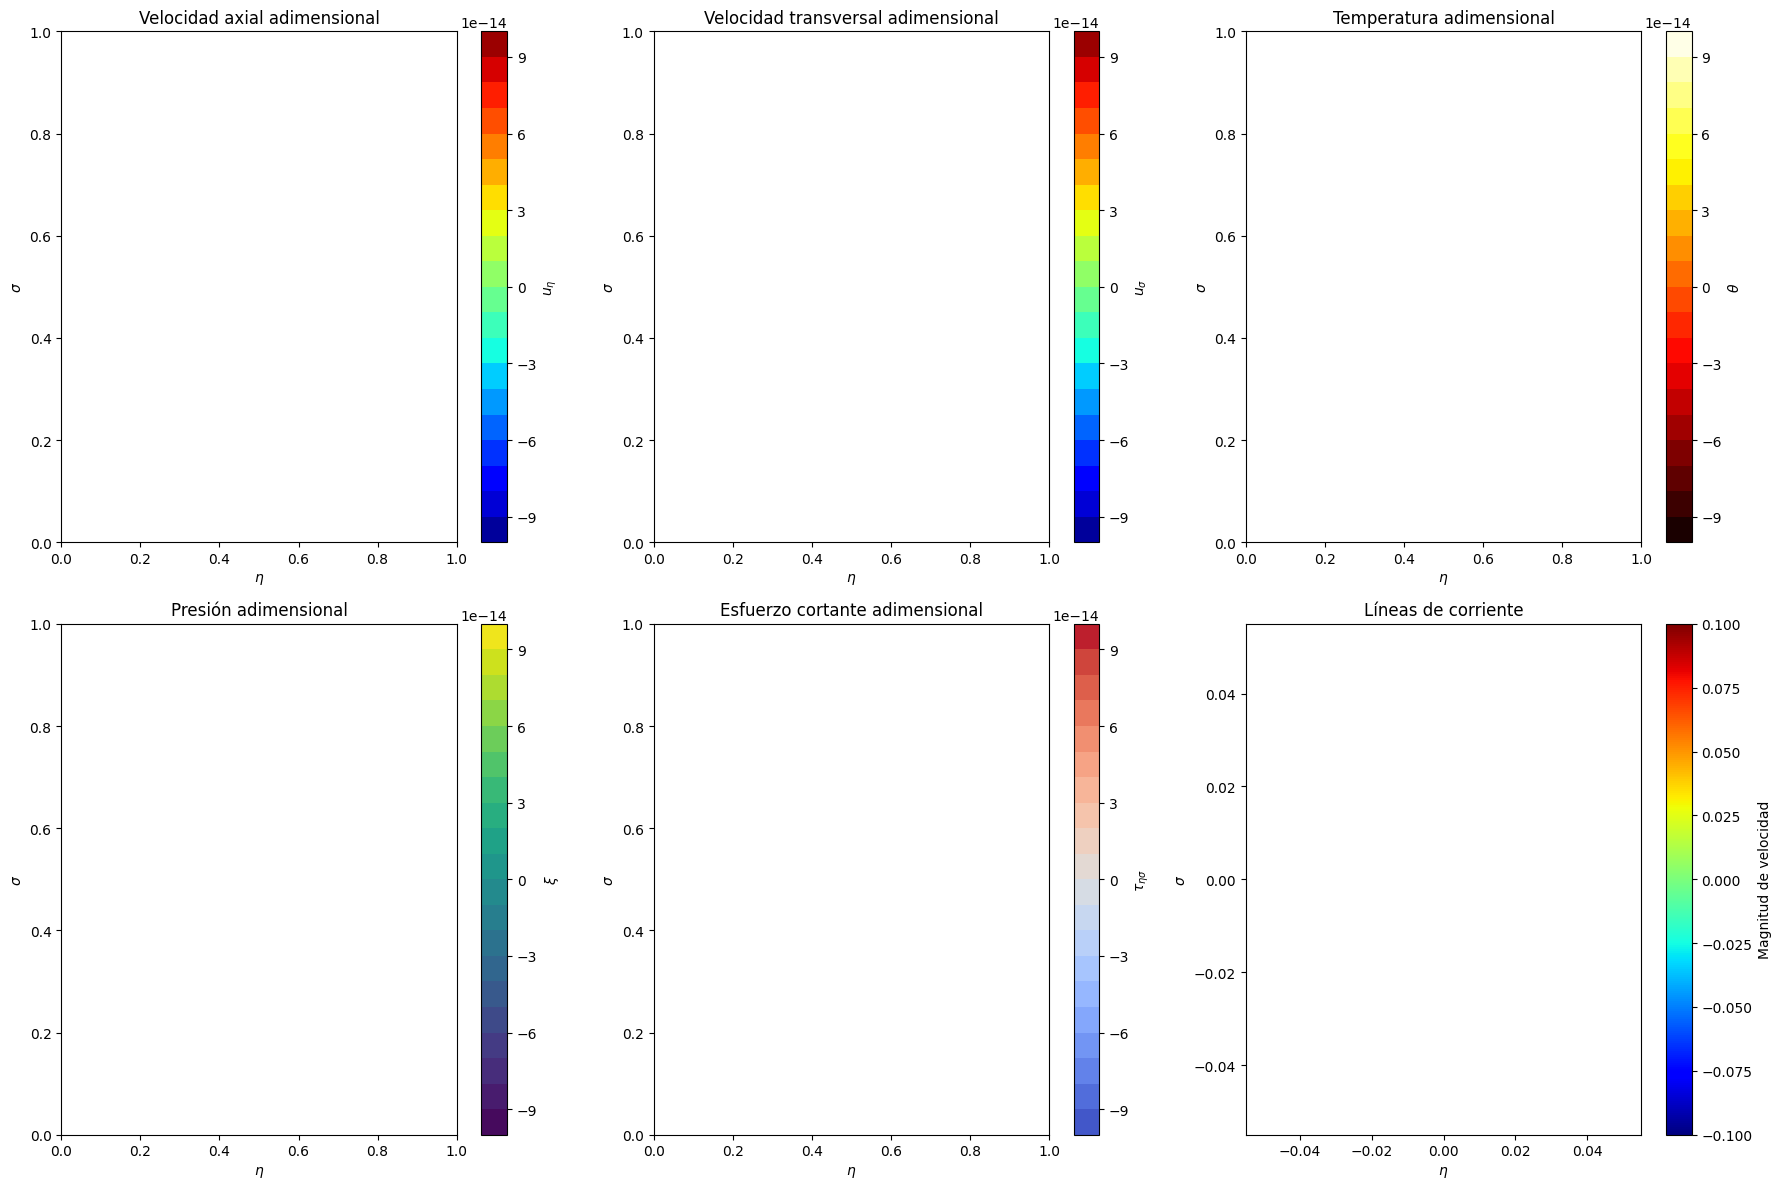

¡Proceso completado!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# PARAMETROS DEL PROBLEMA
# Geometría
Lx, Ly = 1.0, 1.0  # Dimensiones del dominio (x, y)
nx, ny = 50, 50      # Número de puntos en la malla
dx, dy = Lx/(nx-1), Ly/(ny-1)

# =============================================================================
# VALORES CARACTERÍSTICOS PARA EL AIRE (25°C, 1 atm)
# =============================================================================
# Propiedades termofísicas básicas
properties = {
    'k': 0.0262,          # Conductividad térmica [W/(m·K)]
    'ρ': 1.184,           # Densidad [kg/m³]
    'μ': 1.849e-5,        # Viscosidad dinámica [Pa·s]
    'cp': 1006.0,         # Calor específico [J/(kg·K)]
    'α': None,            # Difusividad térmica [m²/s] (se calculará)
    'ν': None,            # Viscosidad cinemática [m²/s] (se calculará)
    'Pr': None            # Número de Prandtl (se calculará)
}

# Escalas características del problema
scales = {
    'L': 10.0,             # Longitud característica [m]
    'H': 1.0,             # Altura característica [m]
    'u0': 2.0,            # Velocidad del fluido [m/s] (sentido +x)
    'up': -1.0,           # Velocidad de la placa [m/s] (sentido -x)
    'T0': 293.0,          # Temperatura de referencia [K]
    'p0': 101325.0,       # Presión de referencia [Pa] (1 atm)
    'pf': None,           # Presión característica [Pa] (se calculará)
    'Tf': None,           # Temperatura característica [K] (se calculará)
    'uc': None            # Velocidad característica corregida [m/s] (se calculará)
}

# =============================================================================
# CÁLCULO DE u_c, T_f Y p_f (CON u_c = u_0 - u_p)
# =============================================================================
def calculate_characteristic_scales(props, scales):
    # 1. Calcular velocidad característica CORREGIDA (u_c = u_0 - u_p)
    scales['uc'] = scales['u0'] - scales['up']  # u0 - (-up) = 2.0 - (-1.0) = 3.0 m/s
    
    # 2. Calcular presión característica (p_f) con u_c
    scales['pf'] = (props['μ'] * scales['uc'] * scales['L']) / (scales['H']**2) + scales['p0']
    
    # 3. Calcular temperatura característica (T_f) con u_c
    scales['Tf'] = scales['T0'] + (props['μ'] * scales['uc']**2) / props['k']
    
    # 4. Calcular propiedades derivadas del aire
    props['α'] = props['k'] / (props['ρ'] * props['cp'])  # Difusividad térmica
    props['ν'] = props['μ'] / props['ρ']                  # Viscosidad cinemática
    props['Pr'] = props['ν'] / props['α']                 # Número de Prandtl
    
    return props, scales

# Calcular todas las escalas y propiedades
properties, scales = calculate_characteristic_scales(properties, scales)

# =============================================================================
# CÁLCULO DE PARÁMETROS ADIMENSIONALES (USANDO u_c EN LUGAR DE u_0)
# =============================================================================
def calculate_dimensionless_params(props, scales):
    dimensionless = {
        'Λ': scales['L'] / scales['H'],                           # Relación de aspecto
        'Re': props['ρ'] * scales['uc'] * scales['L'] / props['μ'], # Reynolds con u_c
        'tc': scales['L'] / scales['uc'],                          # Tiempo característico
        'φ': props['ν'] / (scales['L'] * scales['uc']),            # Parámetro viscoso
        'β': props['α'] * scales['L']**3 / (scales['uc'] * scales['H']**2), # Difusión térmica
        'Eu': (scales['pf'] - scales['p0']) / (props['ρ'] * scales['uc']**2), # Euler con u_c
        'δ': props['μ'] * scales['uc'] / (props['ρ'] * props['cp'] * scales['L']) # Disipación
    }
    return dimensionless

dimensionless = calculate_dimensionless_params(properties, scales)

# =============================================================================
# RESULTADOS IMPRESOS (CON u_c)
# =============================================================================
print("="*80)
print("RESULTADOS CLAVE PARA EL MODELO")
print("="*80)
print(f"Velocidad característica (u_c): {scales['uc']:.2f} m/s")
print(f"Presión característica (p_f): {scales['pf']:.2f} Pa")
print(f"Temperatura característica (T_f): {scales['Tf']:.2f} K")
print(f"Delta de presión (p_f - p0): {(scales['pf'] - scales['p0']):.2f} Pa")
print(f"Delta de temperatura (T_f - T0): {(scales['Tf'] - scales['T0']):.2f} K\n")

print("Propiedades del aire calculadas:")
print(f"Difusividad térmica (α): {properties['α']:.3e} m²/s")
print(f"Viscosidad cinemática (ν): {properties['ν']:.3e} m²/s")
print(f"Número de Prandtl (Pr): {properties['Pr']:.2f}\n")

print("Parámetros adimensionales (usando u_c):")
for key, value in dimensionless.items():
    print(f"{key}: {value:.3e}")


# Tiempo
dt = 0.001           # Paso de tiempo
nt = 500             # Número de pasos de tiempo

## INICIALIZACIÓN

# Mallas
eta = np.linspace(0, Lx, nx)
sigma = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(eta, sigma)

# Campos iniciales
u_eta = np.zeros((ny, nx))         # Velocidad horizontal
u_sigma = np.zeros((ny, nx))       # Velocidad vertical
theta = np.zeros((ny, nx))         # Temperatura
xi = np.zeros((ny, nx))            # Presión

# Aplicar condiciones de frontera
u_eta[0, :] = 0      # Placa inferior móvil
u_eta[-1, :] = 1     # Flujo libre superior
theta[0, :] = 0      # Temperatura de la placa
theta[-1, :] = 0     # Temperatura del fluido lejos de la 

# Historiales
u_history = np.zeros((nt, ny, nx))  # Historial de velocidad U
T_history = np.zeros((nt, ny, nx))  # Historial de temperatura


# EVOLUCIÓN TEMPORAL (ESQUEMA EXPLICITO)
for n in range(nt):
    # Copiar campos anteriores
    u_eta_old = u.copy()
    v_old = v.copy()
    T_old = T.copy()

    # Resolver Navier-Stokes (simplificado)
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Ecuación de u (componente x)
            u[i, j] = (u_eta_old[i, j] + dt * (
                -u_eta_old[i, j] * (u_eta_old[i, j+1] - u_eta_old[i, j-1]) / (2*dx)
                -v_old[i, j] * (u_eta_old[i+1, j] - u_eta_old[i-1, j]) / (2*dy)
                + nu * (
                    (u_eta_old[i, j+1] - 2*u_eta_old[i, j] + u_eta_old[i, j-1]) / dx**2
                    + (u_eta_old[i+1, j] - 2*u_eta_old[i, j] + u_eta_old[i-1, j]) / dy**2
                )
            ))

            # Ecuación de T (temperatura)
            T[i, j] = (T_old[i, j] + dt * (
                -u_eta_old[i, j] * (T_old[i, j+1] - T_old[i, j-1]) / (2*dx)
                -v_old[i, j] * (T_old[i+1, j] - T_old[i-1, j]) / (2*dy)
                + alpha * (
                    (T_old[i, j+1] - 2*T_old[i, j] + T_old[i, j-1]) / dx**2
                    + (T_old[i+1, j] - 2*T_old[i, j] + T_old[i-1, j]) / dy**2
                )
                + (mu / (rho * cp)) * (  # Disipación viscosa (simplificada)
                    2 * ((u_eta_old[i, j+1] - u_eta_old[i, j-1]) / (2*dx))**2
                    + 2 * ((v_old[i+1, j] - v_old[i-1, j]) / (2*dy))**2
                    + ((u_eta_old[i+1, j] - u_eta_old[i-1, j]) / (2*dy) 
                      + (v_old[i, j+1] - v_old[i, j-1]) / (2*dx))**2
                )
            ))

    # Aplicar condiciones de frontera nuevamente
    u[0, :] = U_p
    u[-1, :] = U_0
    v[:, 0] = v[:, -1] = 0
    T[0, :] = T0
    T[-1, :] = T1

    # Almacenar instantánea (AÑADE ESTO)
    u_history[n] = u.copy()  # Usamos copy() para evitar referencias
    T_history[n] = T.copy()

# Cálculo de la presión mediante ecuación de Poisson (simplificado)
# Usamos una aproximación simple basada en la divergencia del campo de velocidad
max_iter = 500  # Número máximo de iteraciones para el solver de presión
tolerance = 1e-4  # Tolerancia para la convergencia

# Inicialización del campo de presión
p = np.zeros((ny, nx))

# Solver iterativo para la presión
for _ in range(max_iter):
    p_old = p.copy()
    
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Aproximación discreta de la ecuación de Poisson para la presión
            p[i, j] = 0.25 * (p_old[i+1, j] + p_old[i-1, j] + 
                             p_old[i, j+1] + p_old[i, j-1] -
                             (rho * dx**2) * (
                                 (u[i+1, j] - u[i-1, j]) / (2*dy) * (v[i, j+1] - v[i, j-1]) / (2*dx) -
                                 ((u[i, j+1] - u[i, j-1]) / (2*dx))**2 -
                                 ((v[i+1, j] - v[i-1, j]) / (2*dy))**2
                             ))
    
    # Condiciones de frontera para la presión (Neumann homogéneas)
    p[0, :] = p[1, :]   # Frontera inferior
    p[-1, :] = p[-2, :] # Frontera superior
    p[:, 0] = p[:, 1]   # Frontera izquierda
    p[:, -1] = p[:, -2] # Frontera derecha
    
    # Criterio de convergencia
    if np.max(np.abs(p - p_old)) < tolerance:
        break

# Encontrar los valores máximos y mínimos de presión
p_max = np.max(p)
p_min = np.min(p)
p_max_coords = np.unravel_index(np.argmax(p), p.shape)
p_min_coords = np.unravel_index(np.argmin(p), p.shape)

# Convertir índices a coordenadas físicas
p_max_x, p_max_y = x[p_max_coords[1]], y[p_max_coords[0]]
p_min_x, p_min_y = x[p_min_coords[1]], y[p_min_coords[0]]

print(f"\nPresión máxima: {p_max:.4f} en ({p_max_x:.2f}, {p_max_y:.2f})")
print(f"Presión mínima: {p_min:.4f} en ({p_min_x:.2f}, {p_min_y:.2f})")

# REPRESENTACIÓN GRÁFICA ACTUALIZADA
plt.figure(figsize=(24, 5))

# Gráfico de velocidad
plt.subplot(1, 4, 1)
plt.contourf(X, Y, u, levels=20, cmap='jet')
plt.colorbar(label='Velocidad (u) [m/s]')
plt.title('Campo de Velocidad Horizontal')
plt.xlabel('x'), plt.ylabel('y')

# Gráfico de temperatura
plt.subplot(1, 4, 2)
plt.contourf(X, Y, T, levels=20, cmap='hot')
plt.colorbar(label='Temperatura (T) [°C]')
plt.title('Distribución de Temperatura')
plt.xlabel('x'), plt.ylabel('y')

# ESFUERZO CORTANTE

# Calcular derivadas para el esfuerzo cortante
dudy = np.gradient(u, dy, axis=0)
dvdx = np.gradient(v, dx, axis=1)
tau_xy = mu * (dudy + dvdx)

# Gráfico de esfuerzo cortante
plt.subplot(1, 4, 3)
plt.contourf(X, Y, tau_xy, levels=20, cmap='viridis')
plt.colorbar(label='Esfuerzo Cortante (τ_xy) [Pa]')
plt.title('Distribución del Esfuerzo Cortante')
plt.xlabel('x'), plt.ylabel('y')

# Nuevo gráfico de presión
plt.subplot(1, 4, 4)
pressure_plot = plt.contourf(X, Y, p, levels=20, cmap='coolwarm')
plt.colorbar(label='Presión (p) [Pa]')
plt.title('Distribución de Presión')
plt.xlabel('x'), plt.ylabel('y')

# Añadir marcadores para máximos/mínimos
plt.scatter(p_max_x, p_max_y, c='red', label=f'Max: {p_max:.2f} Pa')
plt.scatter(p_min_x, p_min_y, c='blue', label=f'Min: {p_min:.2f} Pa')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =============================================
# PARÁMETROS ADIMENSIONALES
# =============================================
Lx_star, Ly_star = 2.0, 1.0  # Dimensiones adimensionales
nx, ny = 50, 50               # Puntos en la malla
dx_star = Lx_star/(nx-1)      # Paso espacial x
dy_star = Ly_star/(ny-1)      # Paso espacial y

# Números adimensionales
Re = 20.0                     # Reynolds
Pr = 10.0                     # Prandtl
Ec = 0.1                      # Eckert

# Condiciones de frontera
U_p_star = -0.5               # Velocidad placa
U_inf_star = 1.0              # Velocidad flujo libre
T0_star, T1_star = 1.0, 0.0   # Temperaturas

# Tiempo
dt_star = 0.001               # Paso temporal
nt = 500                      # Pasos totales

# =============================================
# INICIALIZACIÓN
# =============================================
x_star = np.linspace(0, Lx_star, nx)
y_star = np.linspace(0, Ly_star, ny)
X_star, Y_star = np.meshgrid(x_star, y_star)

u_star = np.zeros((ny, nx)) + U_inf_star
v_star = np.zeros((ny, nx))
T_star = np.zeros((ny, nx)) + T1_star
p_star = np.zeros((ny, nx))

u_star[0, :] = U_p_star
u_star[-1, :] = U_inf_star
T_star[0, :] = T0_star
T_star[-1, :] = T1_star

# =============================================
# SIMULACIÓN
# =============================================
u_history, v_history, T_history = [], [], []

for n in range(nt):
    u_old, v_old, T_old = u_star.copy(), v_star.copy(), T_star.copy()

    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Ecuación de momento x
            conv_u = -u_old[i,j]*(u_old[i,j+1]-u_old[i,j-1])/(2*dx_star) \
                     -v_old[i,j]*(u_old[i+1,j]-u_old[i-1,j])/(2*dy_star)
            diff_u = (1/Re)*((u_old[i,j+1]-2*u_old[i,j]+u_old[i,j-1])/dx_star**2 \
                            + (u_old[i+1,j]-2*u_old[i,j]+u_old[i-1,j])/dy_star**2)
            u_star[i,j] = u_old[i,j] + dt_star*(conv_u + diff_u)
            
            # Ecuación de energía
            conv_T = -u_old[i,j]*(T_old[i,j+1]-T_old[i,j-1])/(2*dx_star) \
                     -v_old[i,j]*(T_old[i+1,j]-T_old[i-1,j])/(2*dy_star)
            diff_T = (1/(Re*Pr))*((T_old[i,j+1]-2*T_old[i,j]+T_old[i,j-1])/dx_star**2 \
                                 + (T_old[i+1,j]-2*T_old[i,j]+T_old[i-1,j])/dy_star**2)
            
            # Disipación viscosa
            Sxx = (u_old[i,j+1]-u_old[i,j-1])/(2*dx_star)
            Syy = (v_old[i+1,j]-v_old[i-1,j])/(2*dy_star)
            Sxy = 0.5*((u_old[i+1,j]-u_old[i-1,j])/(2*dy_star) \
                      + (v_old[i,j+1]-v_old[i,j-1])/(2*dx_star))
            viscous_heating = (Ec/Re)*(2*(Sxx**2 + Syy**2) + 4*Sxy**2)
            
            T_star[i,j] = T_old[i,j] + dt_star*(conv_T + diff_T + viscous_heating)

    # Condiciones de frontera
    v_star[:, 0], v_star[:, -1] = v_star[:, -2], v_star[:, 1]
    u_star[0, :], u_star[-1, :] = U_p_star, U_inf_star
    v_star[0, :], v_star[-1, :] = 0, 0
    T_star[0, :], T_star[-1, :] = T0_star, T1_star
    
    if n % 10 == 0:
        u_history.append(u_star.copy())
        v_history.append(v_star.copy())
        T_history.append(T_star.copy())

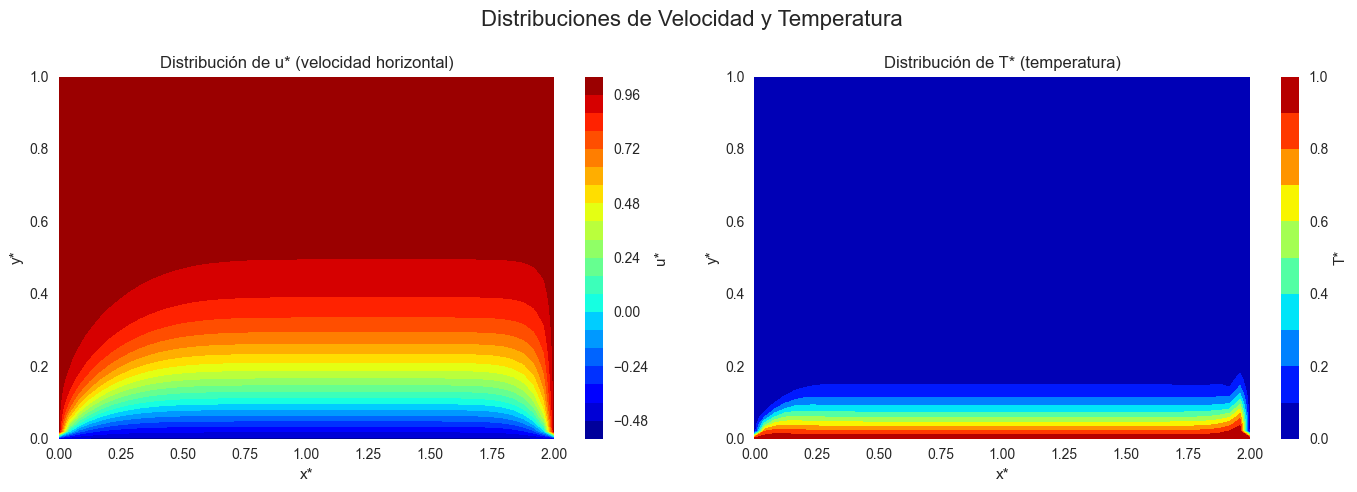

In [22]:

# =============================================
# VISUALIZACIÓN DE RESULTADOS FINALES
# =============================================

# Crear figura con 4 subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuciones de Velocidad y Temperatura', fontsize=16)

# 2. Mapa de contorno de velocidad horizontal u*
contour_u = axs[0].contourf(X_star, Y_star, u_star, levels=20, cmap='jet')
plt.colorbar(contour_u, ax=axs[0], label='u*')
axs[0].set_title('Distribución de u* (velocidad horizontal)')
axs[0].set_xlabel('x*')
axs[0].set_ylabel('y*')

# 4. Mapa de contorno de temperatura T*
contour_T = axs[1].contourf(X_star, Y_star, T_star, levels=10, cmap='jet')
plt.colorbar(contour_T, ax=axs[1], label='T*')
axs[1].set_title('Distribución de T* (temperatura)')
axs[1].set_xlabel('x*')
axs[1].set_ylabel('y*')

plt.tight_layout()
plt.show()

In [23]:
# =============================================
# VISUALIZACIÓN
# =============================================
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

def update(frame):
    ax1.clear(), ax2.clear()
    
    # Campo de velocidad
    speed = np.sqrt(u_history[frame]**2 + v_history[frame]**2)
    im1 = ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
    ax1.streamplot(X_star, Y_star, u_history[frame], v_history[frame], color='k', density=1.5)
    ax1.set_title(f'Velocidad (t*={frame*10*dt_star:.2f})')
    ax1.set_xlabel('x*'), ax1.set_ylabel('y*')
    plt.colorbar(im1, ax=ax1, label='|u*|')
    
    # Campo de temperatura
    im2 = ax2.contourf(X_star, Y_star, T_history[frame], levels=20, cmap='hot')
    ax2.set_title('Temperatura adimensional')
    ax2.set_xlabel('x*'), ax2.set_ylabel('y*')
    plt.colorbar(im2, ax=ax2, label='T*')
    
    plt.tight_layout()

# ani = FuncAnimation(fig, update, frames=len(u_history), interval=100)
anim = FuncAnimation(fig, animate, frames=Nt, interval=50, blit=True)

HTML(anim.to_jshtml())

NameError: name 'animate' is not defined